In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scienceplots
import networkx as nx

from nanonets import Simulation
from nanonets.utils import load_simulation_results, get_net_currents, create_weighted_undirected_graph, display_net_flow_graph

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 320
V_INPUT     = np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS, endpoint=False)
V_I_PLOT    = 1000*V_INPUT
N_NETS      = 32
R_VALUES    = [100,1600]
PATH        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/res_disorder/"
PATH_U        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/network/"

In [ ]:
data_u  = pd.read_csv(f"{PATH_U}Nx=9_Ny=9_Ne=8.csv").sort_values(by='E0',ignore_index=True)
data    = {R : [pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=8_mean2_{R}_{i}.csv").sort_values(by='E0',ignore_index=True) for i in range(N_NETS)] for R in R_VALUES}

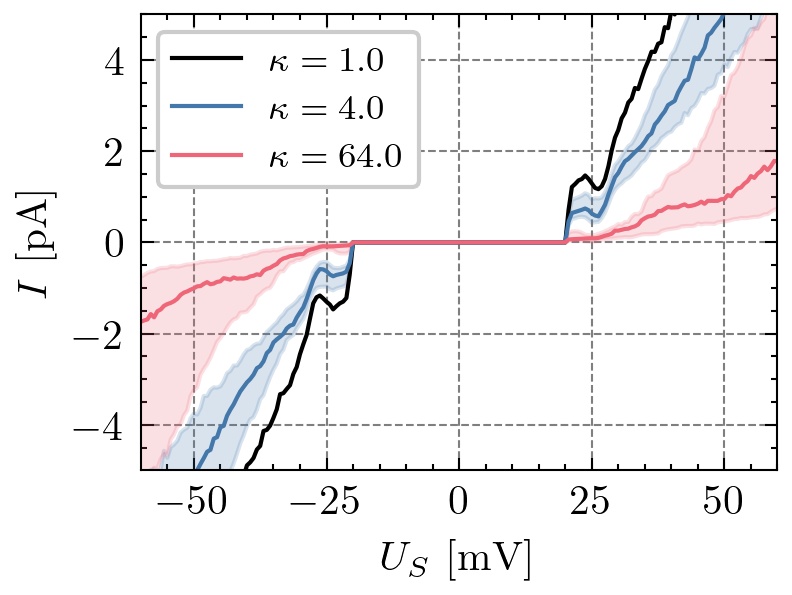

In [65]:
fig     = plt.figure(dpi=300, layout='constrained')
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
y_u     = data_u['Observable']
_       = ax.plot(1000*V_INPUT, y_u*1e-6, label='$\\kappa = 1.0$', color='black')

for R in R_VALUES:
    y_data      = [data[R][i]['Observable'].values for i in range(N_NETS)]
    y_median    = np.median(y_data,axis=0)*1e-6
    y_90        = np.quantile(y_data,0.9,axis=0)*1e-6
    y_10        = np.quantile(y_data,0.1,axis=0)*1e-6
    pp          = ax.errorbar(1000*V_INPUT, y_median, label=f"$\\kappa = {R/25}$")
    _           = ax.fill_between(1000*V_INPUT, y_10, y_90, color=pp[0].get_color(), alpha=0.2)

_   = ax.legend(fontsize='small')
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-60,60)
_   = ax.set_ylim(-5,5)

fig.savefig(f"plots/svg/network_iv_curves_vs_R_disorder.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_vs_R_disorder.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_vs_R_disorder.png", transparent=False)

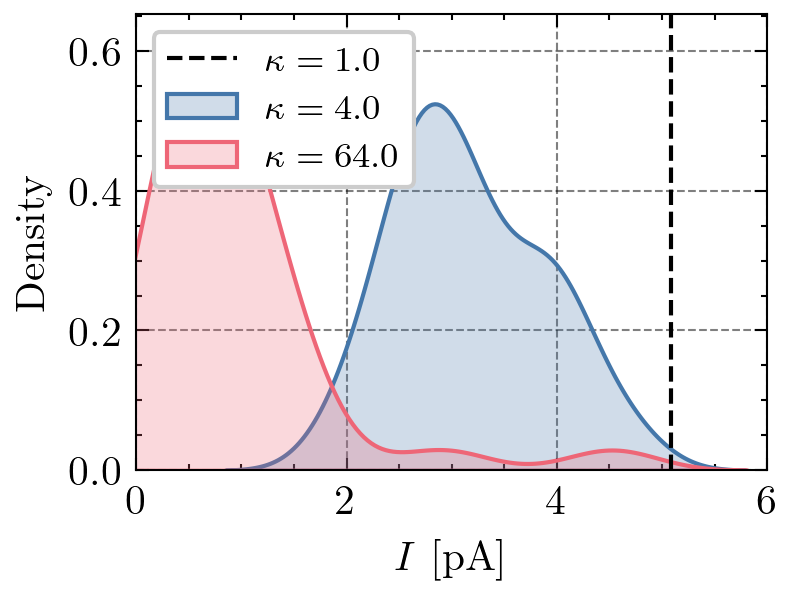

In [64]:
fig     = plt.figure(dpi=300, layout='constrained')
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = plt.axvline(y_u[224]*1e-6, color='black', ls='--', label=f"$\\kappa = 1.0$")

for R in R_VALUES:
    _   = sns.kdeplot([data[R][i]['Observable'][224]*1e-6 for i in range(N_NETS)], fill=True, label=f"$\\kappa = {R/25}$")

_ = ax.set_xlabel("$I~[\mathrm{pA}]$")
_ = ax.set_xlim(0,6)
_ = ax.legend(fontsize='small')

fig.savefig(f"plots/svg/network_current_dist_vs_R_disorder.svg", transparent=True)
fig.savefig(f"plots/pdf/network_current_dist_vs_R_disorder.pdf", transparent=False)
fig.savefig(f"plots/png/network_current_dist_vs_R_disorder.png", transparent=False)

In [ ]:
net_currents_u = pd.read_csv(f"{PATH_U}net_currents_Nx=9_Ny=9_Ne=8.csv")
net_currents   = {R : [pd.read_csv(f"{PATH}net_currents_Nx=9_Ny=9_Ne=8_mean2_{R}_{i}.csv") for i in range(N_NETS)] for R in R_VALUES}
data_ref       = {R : [pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=8_mean2_{R}_{i}.csv") for i in range(N_NETS)] for R in R_VALUES}

In [ ]:
L           = 9
topo        = {"Nx": L,"Ny": L, "e_pos": [[(L-1)//2, 0],[0, 0],[L-1, 0],
                [0, (L-1)//2],[L-1, (L-1)//2],[0, L-1],
                [L-1, L-1],[(L-1)//2, L-1]],
            "electrode_type": ['constant']*8}
sim_class   = Simulation(topo)
pos         = sim_class.get_positions()
pos         = {(key+8 if key >= 0 else (abs(key)-1)) : (val) for key, val in pos.items()}
j_vals      = [202, 209 , 230]

In [175]:
G_dicts = {}
j_dicts = {}
for R in R_VALUES:
    G_dicts[R] = []
    j_dicts[R] = []
    for i in range(N_NETS):
        df_tmp  = get_net_currents(net_currents[R][i])
        s_tmp   = np.sqrt((df_tmp**2).sum())*1e-6
        G       = create_weighted_undirected_graph(1/s_tmp)
        G_dicts[R].append(G)
        j_dicts[R].append(s_tmp.values)

s_u = np.sqrt((get_net_currents(net_currents_u)**2).sum())*1e-6
G_u = create_weighted_undirected_graph(1/s_u)

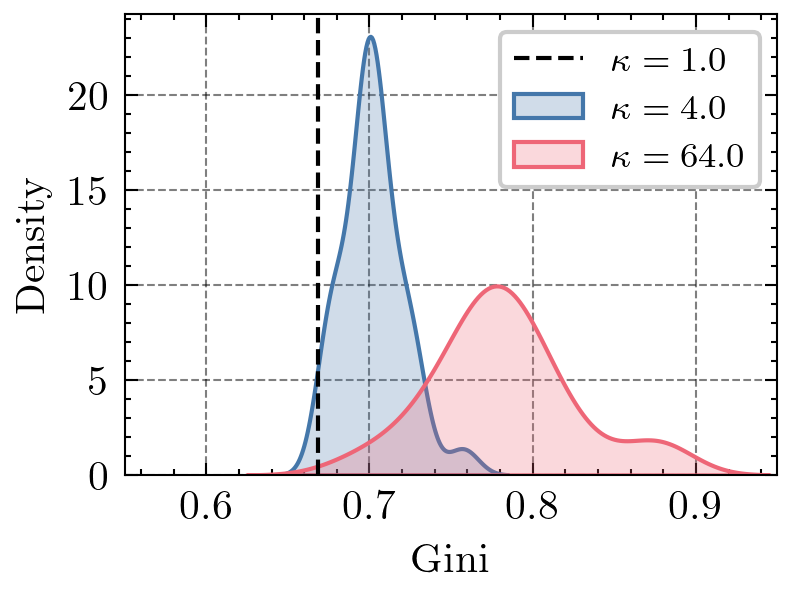

In [176]:
def calculate_gini(currents):
    """
    Calculates the Gini coefficient of a 1D array of junction currents.
    A Gini of 0 means perfect equality (uniform current).
    A Gini of 1 means perfect inequality (all current flows through 1 edge).
    """
    # Ensure it's a numpy array of positive floats
    x = np.abs(np.array(currents, dtype=np.float64))
    
    # Safety check for a completely dead network
    if np.sum(x) == 0:
        return 0.0
        
    # Sort the values
    x = np.sort(x)
    n = len(x)
    
    # Vectorized Gini calculation
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))
    
    return gini

fig     = plt.figure(dpi=300, layout='constrained')
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = plt.axvline(calculate_gini(s_u), color='black', ls='--', label=f"$\\kappa = 1.0$")
for R in R_VALUES:
    ginis = [calculate_gini(val) for val in j_dicts[R]]
    _ = sns.kdeplot(ginis, fill=True, label=f"$\\kappa = {R/25}$")

_ = ax.set_xlabel("Gini")
_ = ax.set_xlim(0.55,0.95)
_ = ax.legend(fontsize='small')

fig.savefig(f"plots/svg/gini_vs_R_disorder.svg", transparent=True)
fig.savefig(f"plots/pdf/gini_vs_R_disorder.pdf", transparent=False)
fig.savefig(f"plots/png/gini_vs_R_disorder.png", transparent=False)

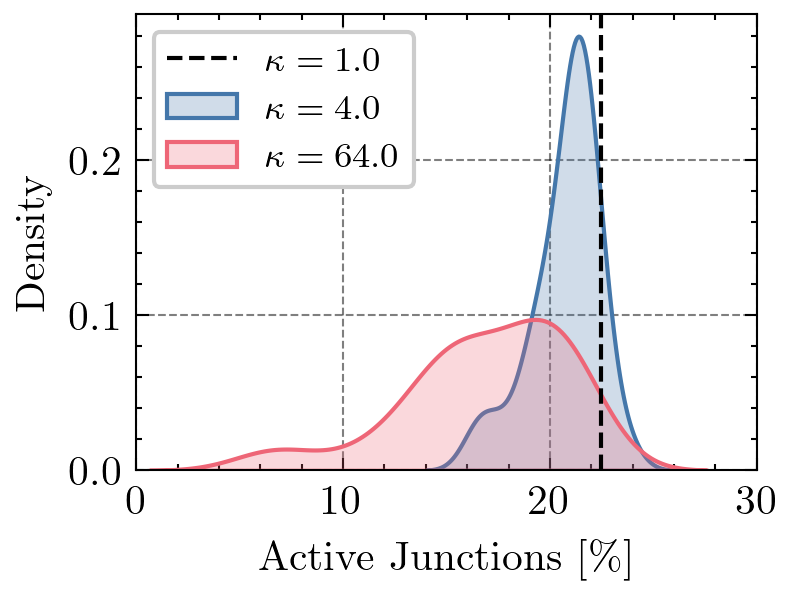

In [181]:
def calculate_ipr(currents):
    """
    Calculates the Inverse Participation Ratio (IPR) for a 1D array of currents.
    """
    x = np.abs(np.array(currents, dtype=np.float64))
    
    total_current = np.sum(x)
    
    # Safety check for a completely dead network
    if total_current == 0:
        return 0.0
        
    # Normalize weights to sum to 1
    w = x / total_current
    
    # IPR is the sum of squared weights
    ipr = np.sum(w**2)
    return ipr

def calculate_effective_edges(currents):
    """
    Returns the effective number of actively participating junctions.
    For a fully uniform network, this approaches N_total_edges.
    For a highly filamentary/bottlenecked network, this drops to a small integer.
    """
    ipr = calculate_ipr(currents)
    if ipr == 0:
        return 0.0
    return 1.0 / ipr

fig     = plt.figure(dpi=300, layout='constrained')
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = plt.axvline(100*calculate_effective_edges(s_u)/len(s_u), color='black', ls='--', label=f"$\\kappa = 1.0$")
for R in R_VALUES:
    ginis = 100*np.array([calculate_effective_edges(val) for val in j_dicts[R]])/len(s_u)
    _ = sns.kdeplot(ginis, fill=True, label=f"$\\kappa = {R/25}$")

# _ = ax.set_xlabel("$N_{edges}$")
_ = ax.set_xlabel("Active Junctions [\%]")
_ = ax.set_xlim(0,30)
_ = ax.legend(fontsize='small')

fig.savefig(f"plots/svg/effective_edges_vs_R_disorder.svg", transparent=True)
fig.savefig(f"plots/pdf/effective_edges_vs_R_disorder.pdf", transparent=False)
fig.savefig(f"plots/png/effective_edges_vs_R_disorder.png", transparent=False)

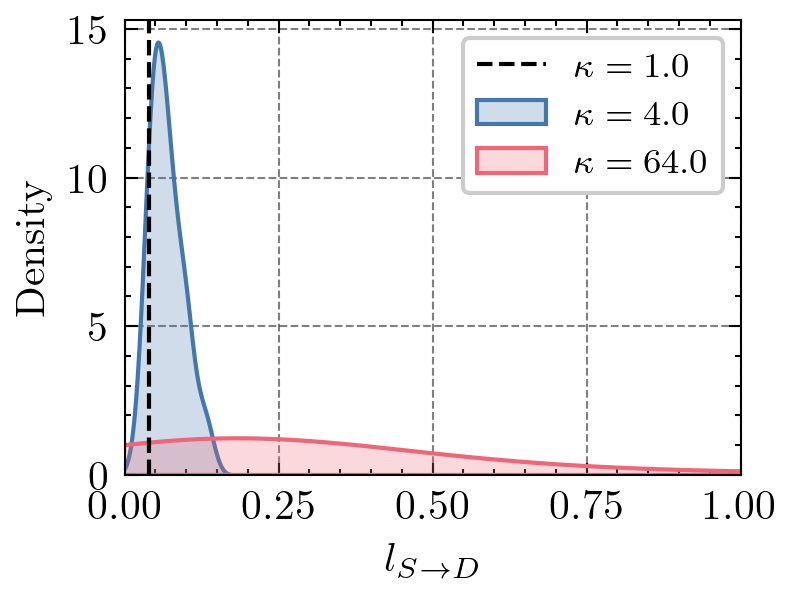

In [182]:
fig     = plt.figure(dpi=300, layout='constrained')
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = plt.axvline(nx.shortest_path_length(G=G_u, source=0, target=7, weight='weight'), color='black', ls='--', label=f"$\\kappa = 1.0$")
for R in R_VALUES:
    ginis = [nx.shortest_path_length(G=val, source=0, target=7, weight='weight') for val in G_dicts[R]]
    _ = sns.kdeplot(ginis, fill=True, label=f"$\\kappa = {R/25}$")

_ = ax.set_xlabel("$l_{S \\to D}$")
_ = ax.set_xlim(0,1)
_ = ax.legend(fontsize='small')

fig.savefig(f"plots/svg/shortest_path_vs_R_disorder.svg", transparent=True)
fig.savefig(f"plots/pdf/shortest_path_vs_R_disorder.pdf", transparent=False)
fig.savefig(f"plots/png/shortest_path_vs_R_disorder.png", transparent=False)